In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
import os


In [2]:
# =============================================================================
# 1. BLOQUE DE CONFIGURACIÓN
# =============================================================================

ARCHIVO_DATOS = "C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Medidas_Arturo/D_Reset_Run35_PP_Ohm.txt"

# Configuración del Algoritmo Genético (Límites de búsqueda para R)
# El algoritmo buscará R entre 100 Ohms y 1 GigaOhm (1e9). Ajusta si es necesario.
LIMITES = [
    (1000, 1e4),  # 1. Resistencia (Ohmios)
]


In [3]:
# =============================================================================
# 2. MODELO SIMPLE (LEY DE OHM)
# =============================================================================


def simular_curva_ohmica(voltajes, R):
    """
    Calcula la curva I-V usando I = V / R.
    Al ser lineal, no necesitamos bucles for, usamos operaciones vectoriales de numpy.
    """
    # Evitamos división por cero o R negativo si el algoritmo prueba cosas raras
    if R <= 0:
        return np.ones_like(voltajes) * 1e-99

    # Cálculo directo vectorizado
    corrientes_sim = voltajes / R
    
    # Devolvemos valor absoluto para evitar problemas con logaritmos en el ajuste
    return np.abs(corrientes_sim)


In [4]:
# =============================================================================
# 3. ALGORITMO GENÉTICO
# =============================================================================


def costo_hibrido_ohmico(genes, v_exp, i_exp_abs):
    """
    Función de costo para optimizar R.
    """
    # Desempaquetamos el único gen
    R = genes[0]

    # Restricción fuerte: R debe ser positivo
    if R <= 0:
        return 1e99

    # Simulamos
    i_sim = simular_curva_ohmica(v_exp, R)

    # Filtro para evitar log(0) o valores muy bajos
    mask = (i_exp_abs > 1e-25) & (i_sim > 1e-25)

    # Si no hay puntos válidos, retornamos error alto
    if np.sum(mask) < 2:
        return 1e99

    log_exp = np.log10(i_exp_abs[mask])
    log_sim = np.log10(i_sim[mask])

    # 1. Error de Magnitud (RMSE en escala logarítmica)
    mse_val = np.mean((log_exp - log_sim) ** 2)

    # En un ajuste lineal simple (I=V/R), el error de pendiente es menos crítico
    # que en modelos exponenciales, pero ayuda a converger más rápido.
    grad_exp = np.gradient(log_exp)
    grad_sim = np.gradient(log_sim)
    mse_grad = np.mean((grad_exp - grad_sim) ** 2)

    costo_total = mse_val + (1.0 * mse_grad)

    return costo_total


--- AJUSTE DE CURVA OHMICA (I = V/R) ---
Datos cargados. Puntos: 51
differential_evolution step 1: f(x)= 0.0012445922449961077
differential_evolution step 2: f(x)= 0.000162441783659246
differential_evolution step 3: f(x)= 0.000162441783659246
differential_evolution step 4: f(x)= 0.000162441783659246
differential_evolution step 5: f(x)= 0.000162441783659246
differential_evolution step 6: f(x)= 0.000162441783659246
differential_evolution step 7: f(x)= 0.0001582762705659093
differential_evolution step 8: f(x)= 0.00014633355051270986
differential_evolution step 9: f(x)= 0.00014593035165345376
differential_evolution step 10: f(x)= 0.00014593035165345376
differential_evolution step 11: f(x)= 0.00014593035165345376
differential_evolution step 12: f(x)= 0.00014541783400636568
Polishing solution with 'L-BFGS-B'

Resistencia Óptima (R): 1.0208e+03 Ohmios


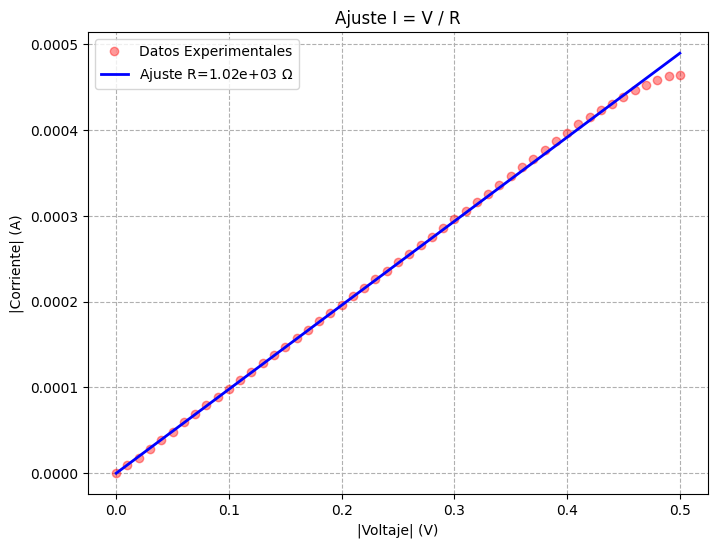

In [5]:
# =============================================================================
# 4. EJECUCIÓN
# =============================================================================

print("--- AJUSTE DE CURVA OHMICA (I = V/R) ---")

# Cargar datos
# Asegúrate de que la ruta exista, si da error usa r"Ruta" o dobles barras //
ruta_datos = ARCHIVO_DATOS
if not os.path.exists(ruta_datos):
    print(f"Error: No se encuentra el archivo en {ruta_datos}")
else:
    datos = np.loadtxt(ruta_datos, skiprows=1)  # Ajusta skiprows si tienes cabecera

    # Asignación de columnas (Revisa que coincidan con tu archivo txt)
    # Suponiendo Col 2: Voltaje, Col 1: Corriente (como en tu código original)
    V_exp = datos[:, 2]
    I_exp = datos[:, 1]

    # Trabajamos con valores absolutos para simplificar el ajuste logarítmico
    # (Asumiendo comportamiento simétrico o ajustando la magnitud de R)
    V_exp_abs = np.abs(V_exp)
    I_exp_abs = np.abs(I_exp)

    print(f"Datos cargados. Puntos: {len(V_exp)}")

    # EJECUTAR AJUSTE
    # differential_evolution es robusto para encontrar el orden de magnitud correcto de R
    resultado = differential_evolution(
        costo_hibrido_ohmico,
        bounds=LIMITES,
        args=(V_exp_abs, I_exp_abs),
        strategy="best1bin",
        popsize=15,  # Reducido porque el problema es más simple (1 variable)
        maxiter=1000,  # Reducido porque converge rápido
        disp=True,
    )

    # RESULTADOS
    best_R = resultado.x[0]
    print("\n" + "=" * 40)
    print(f"Resistencia Óptima (R): {best_R:.4e} Ohmios")
    print("=" * 40)

    # GRAFICAR
    I_fit = simular_curva_ohmica(V_exp_abs, best_R)

    plt.figure(figsize=(8, 6))

    # Escala Log-Log suele ser mejor para ver leyes de potencia/ohmicas en rangos amplios
    plt.plot(V_exp_abs, I_exp_abs, "ro", alpha=0.4, label="Datos Experimentales")
    plt.plot(
        V_exp_abs, I_fit, "b-", linewidth=2, label=f"Ajuste R={best_R:.2e} $\\Omega$"
    )

    # plt.yscale("log")
    plt.xlabel("|Voltaje| (V)")
    plt.ylabel("|Corriente| (A)")
    plt.title("Ajuste I = V / R")
    plt.legend()
    plt.grid(True, which="both", linestyle="--")
    plt.show()
